In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/PET_work/work_check/all_scintillators.csv')

# Completeness Analysis: Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

completeness_report = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

print("Completeness Analysis Report:")
print(completeness_report)

Completeness Analysis Report:
                  Missing Values  Missing Percentage
Scintillator                   0            0.000000
Mechanism                      3            1.010101
lightyield                     2            0.673401
dop_conc                      79           26.599327
host_band gap                 50           16.835017
av_el_diel_cons              174           58.585859
av_ion_diel_cons             174           58.585859
reference                      7            2.356902
av_ion_pot                     3            1.010101
ion_pot(+)                     3            1.010101
ion_pot(-)                     3            1.010101
Density (g/cc)                20            6.734007
av_electroneg                 36           12.121212
av.ele(+)                     36           12.121212
av.ele(-)                     36           12.121212
av_elec_aff                    3            1.010101
elec_aff(+)                    3            1.010101
elec_aff(-)     

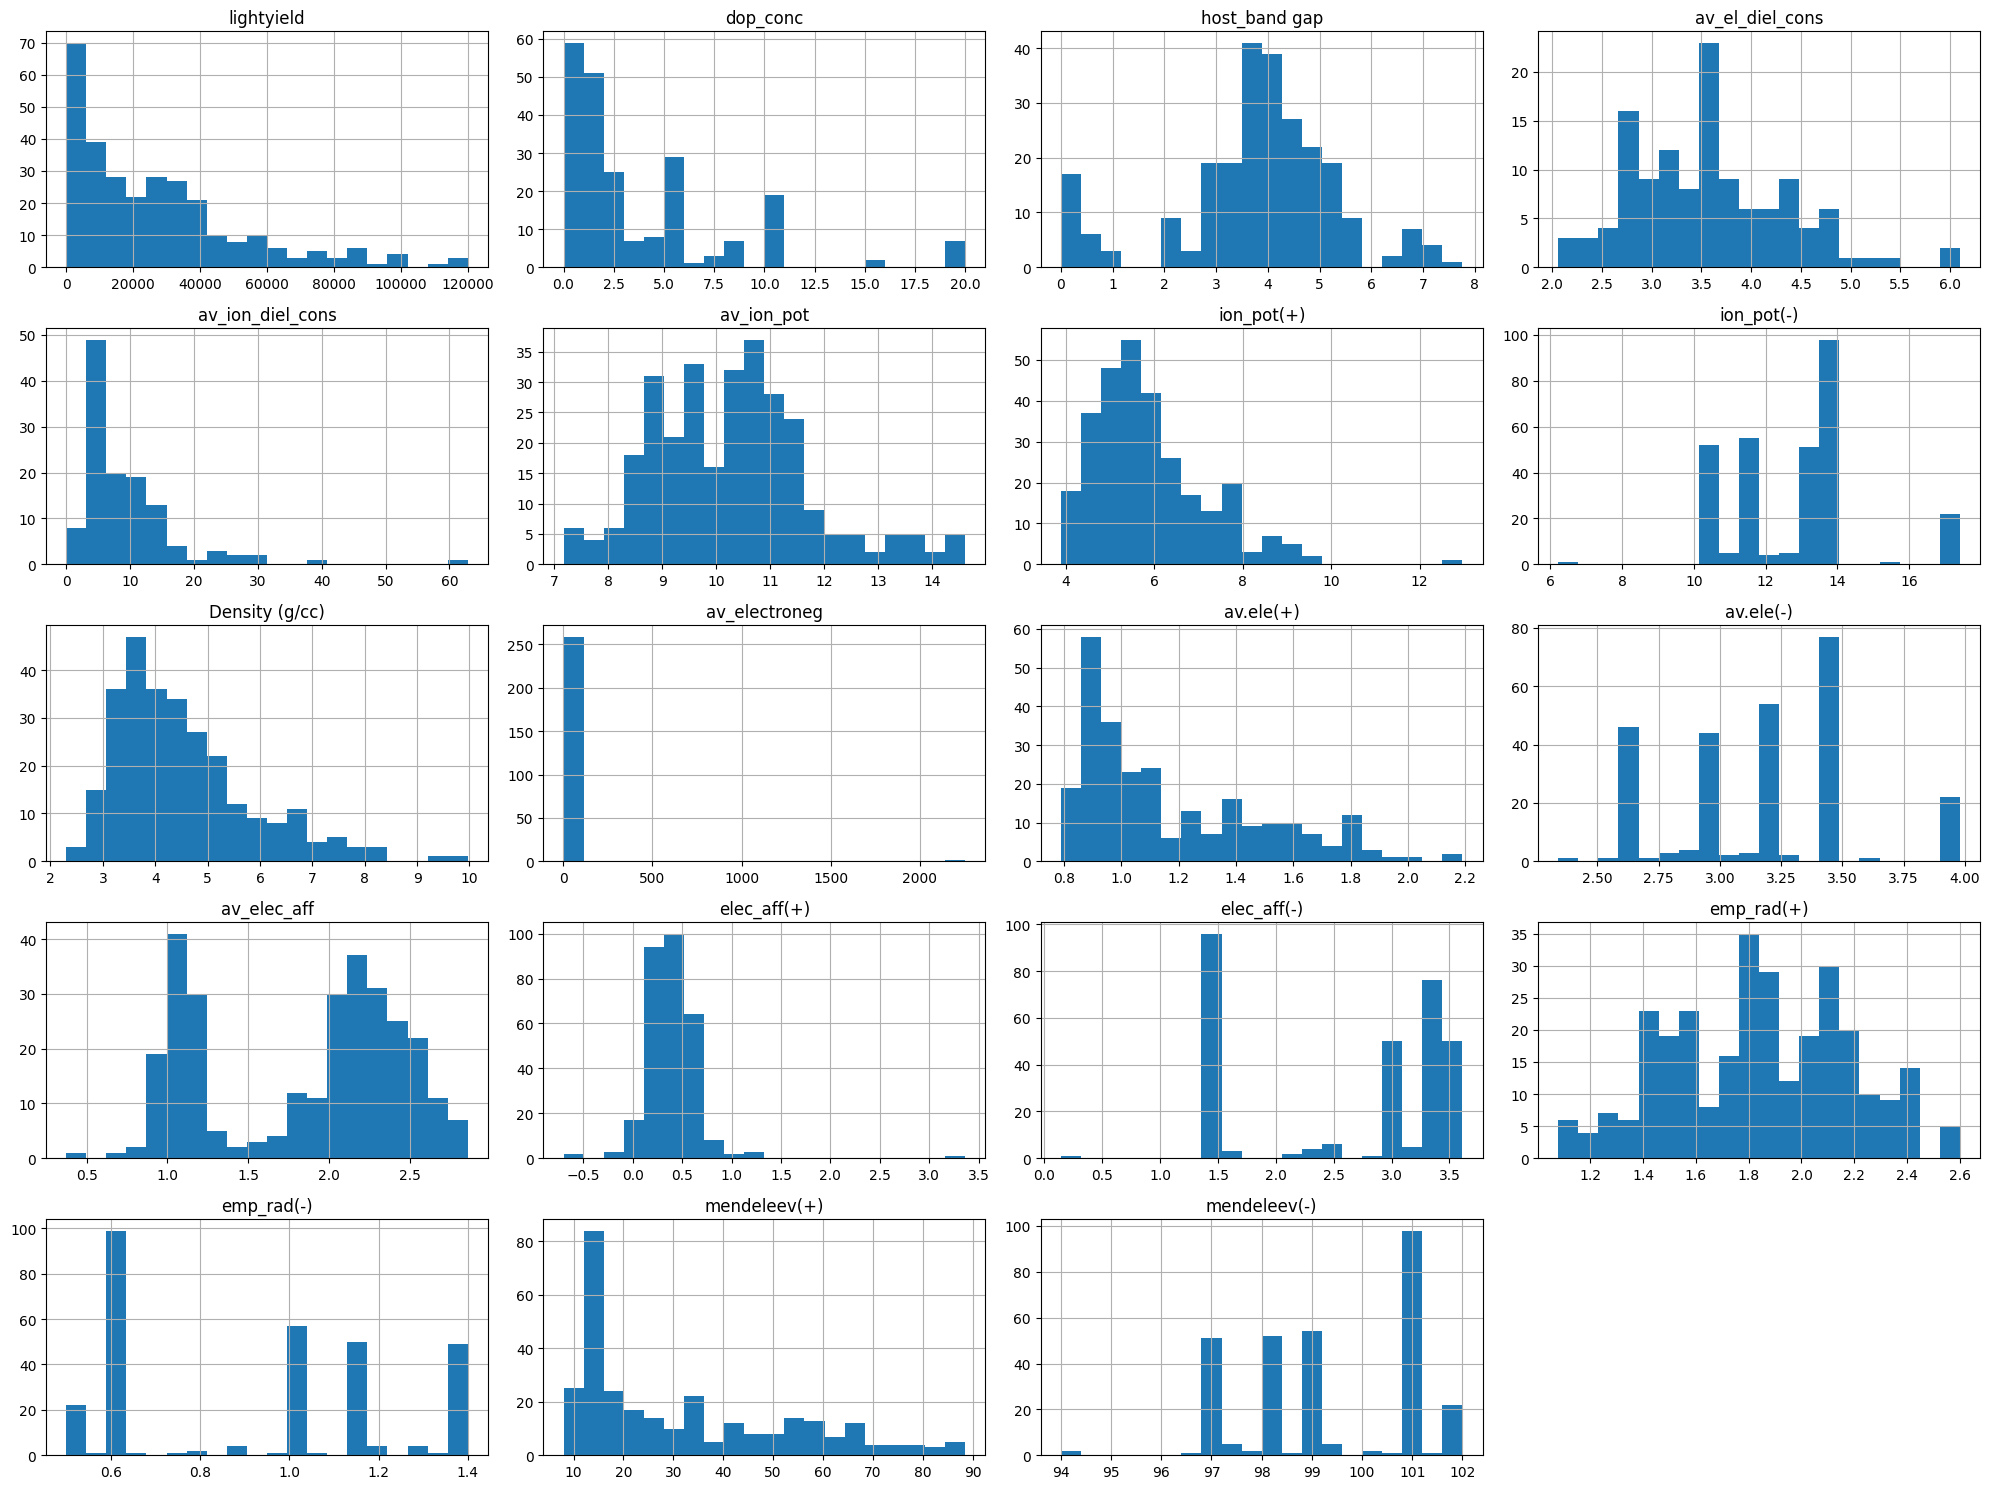

/tmp/ipython-input-2462313423.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compound_counts.values, y=compound_counts.index, palette='viridis')


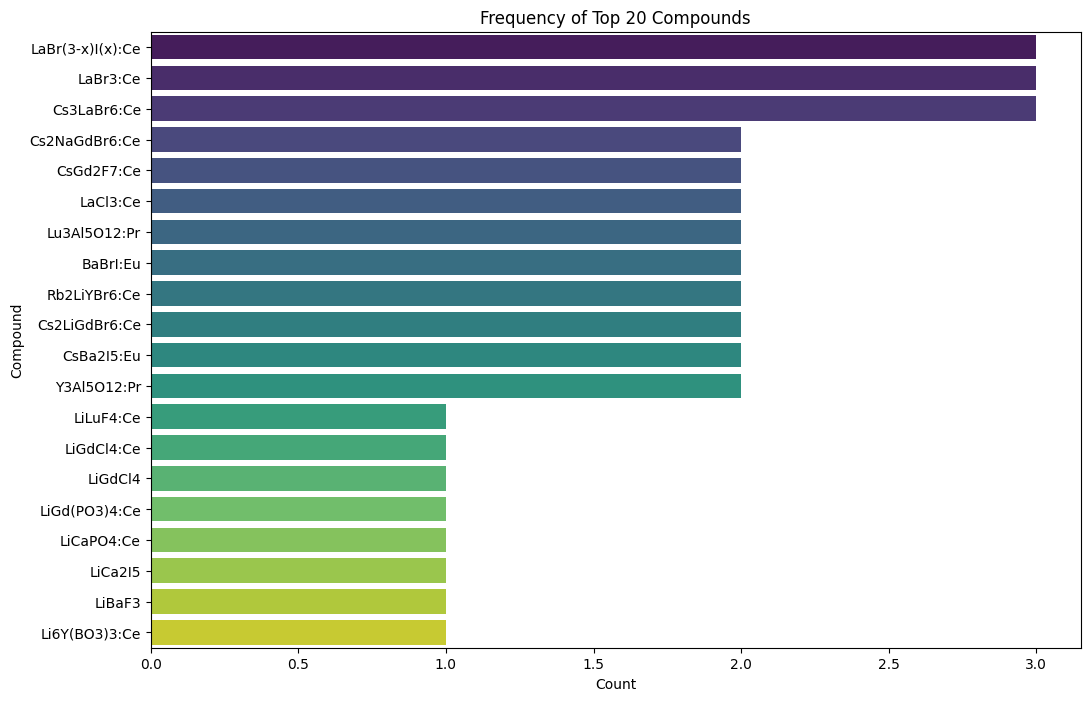

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Analysis: Plotting histograms for all numerical features
df.hist(bins=20, figsize=(20, 15))
plt.tight_layout()
plt.show()

# Distribution Analysis: Balance across material families (using the 'Compound' column to infer families)
# We can analyze the frequency of different compound types
# For simplicity, we'll look at the most frequent compounds.
plt.figure(figsize=(12, 8))
compound_counts = df['Scintillator'].value_counts().head(20) # Top 20 for readability
sns.barplot(x=compound_counts.values, y=compound_counts.index, palette='viridis')
plt.title('Frequency of Top 20 Compounds')
plt.xlabel('Count')
plt.ylabel('Compound')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported successfully.

--- 1. Loading and Assessing Data ---
Dataset loaded successfully.
Cleaned column names.

--- 2. Data Cleaning and Preprocessing ---
Initial number of rows: 295
Number of rows after duplicate removal: 295
Total duplicates removed: 0
Rows before dropping missing 'lightyield': 295
Rows after dropping missing 'lightyield': 295
Total rows dropped due to missing 'lightyield': 0
No columns with high missing values were dropped (or they didn't exist).
No numeric values required imputation.
Data cleaning and imputation complete.

--- 3. Physics-Informed Feature Engineering ---
Engineered features created successfully.

--- 4. Preparing Data for Modeling ---
Data prepared with 19 initial features.

--- Processing Model: RandomForest ---
RFECV selected 18 features.
Hyperparameter tuning complete.

--- Processing Model: GradientBoosting

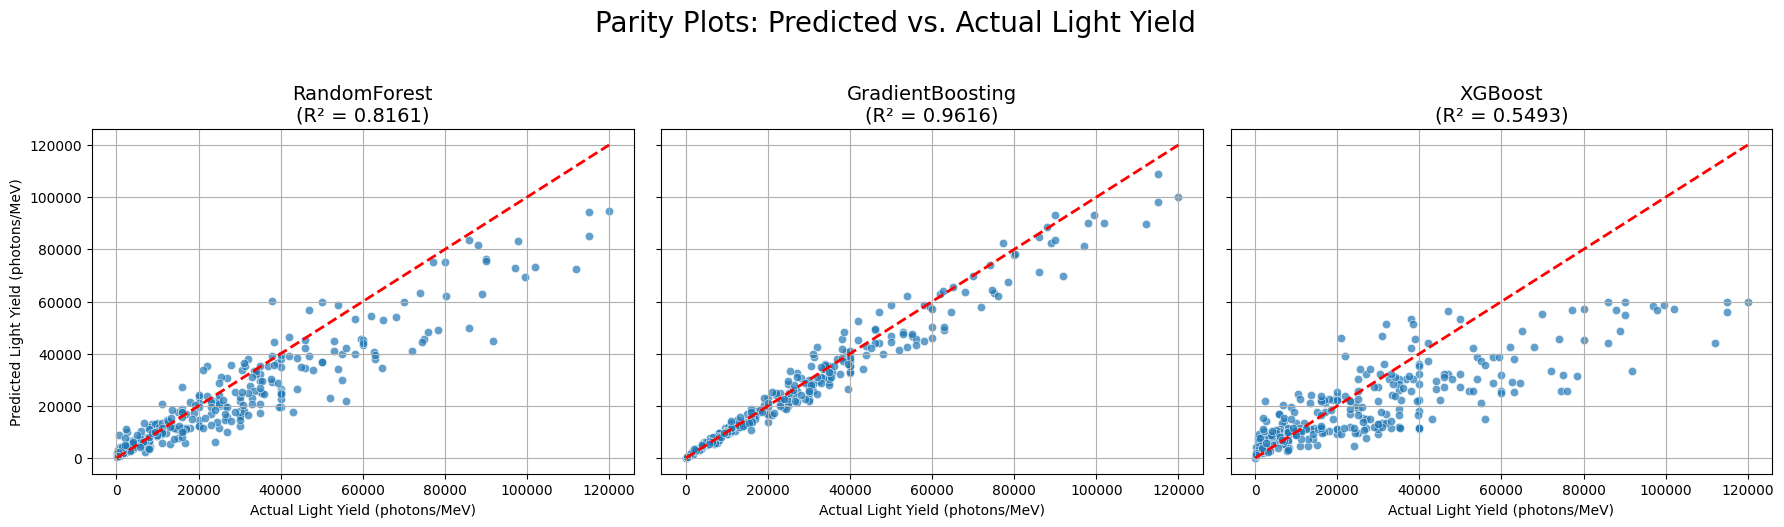

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ==============================================================================
# 0. SETUP AND IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

# ==============================================================================
# 1. DATA LOADING AND INITIAL ASSESSMENT
# ==============================================================================
print("\n--- 1. Loading and Assessing Data ---")
try:
    # Assumes the CSV is in the same directory or a specified path
    df = pd.read_csv('/content/drive/MyDrive/PET_work/all_scintillators_cleaned.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Raw data file 'all_scintillators_cleaned2.csv' not found.")
    exit()

# Clean column names for easier access
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('/', '')
print("Cleaned column names.")

# ==============================================================================
# 2. DATA CLEANING AND PREPROCESSING
# ==============================================================================
print("\n--- 2. Data Cleaning and Preprocessing ---")
df_cleaned = df.copy()

# Log initial row count before duplicate removal
initial_rows_count = len(df_cleaned)
df_cleaned.drop_duplicates(inplace=True)
# Log row count after duplicate removal and calculate removed duplicates
rows_after_duplicate_removal = len(df_cleaned)
duplicates_removed = initial_rows_count - rows_after_duplicate_removal
print(f"Initial number of rows: {initial_rows_count}")
print(f"Number of rows after duplicate removal: {rows_after_duplicate_removal}")
print(f"Total duplicates removed: {duplicates_removed}")

# Log rows before dropping missing 'lightyield' values
rows_before_lightyield_drop = len(df_cleaned)
df_cleaned.dropna(subset=['lightyield'], inplace=True)
rows_after_lightyield_drop = len(df_cleaned)
rows_lightyield_dropped = rows_before_lightyield_drop - rows_after_lightyield_drop
print(f"Rows before dropping missing 'lightyield': {rows_before_lightyield_drop}")
print(f"Rows after dropping missing 'lightyield': {rows_after_lightyield_drop}")
print(f"Total rows dropped due to missing 'lightyield': {rows_lightyield_dropped}")

# Drop columns with a high number of missing values if they exist
cols_to_drop_high_missing = ['av_el_diel_cons', 'av_ion_diel_cons']
dropped_columns_this_step = []
for col in cols_to_drop_high_missing:
    if col in df_cleaned.columns:
        df_cleaned.drop(columns=[col], inplace=True)
        dropped_columns_this_step.append(col)
if dropped_columns_this_step:
    print(f"Dropped columns with high missing values: {', '.join(dropped_columns_this_step)}")
else:
    print("No columns with high missing values were dropped (or they didn't exist).")

# Impute missing numeric values with the median
numeric_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('lightyield') # Exclude target variable from imputation

imputed_counts = {}
for col in numeric_cols:
    if df_cleaned[col].isnull().any():
        missing_count = df_cleaned[col].isnull().sum()
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
        imputed_counts[col] = missing_count

if imputed_counts:
    print("Missing numeric values imputed with median:")
    for col, count in imputed_counts.items():
        print(f"  - '{col}': {count} values imputed")
else:
    print("No numeric values required imputation.")

print("Data cleaning and imputation complete.")

# ==============================================================================
# 3. PHYSICS-INFORMED FEATURE ENGINEERING
# ==============================================================================
print("\n--- 3. Physics-Informed Feature Engineering ---")
epsilon = 1e-6
df_cleaned['electronegativity_mismatch'] = np.abs(df_cleaned['av.ele+'] - df_cleaned['av.ele-'])
df_cleaned['size_mismatch'] = np.abs(df_cleaned['emp_rad+'] - df_cleaned['emp_rad-']) / (df_cleaned['emp_rad+'] + df_cleaned['emp_rad-'] + epsilon)
df_cleaned['bandgap_doping_ratio'] = df_cleaned['host_band_gap'] / (df_cleaned['dop_conc'] + epsilon)
print("Engineered features created successfully.")

# ==============================================================================
# 4. PREPARE DATA FOR MODELING (X AND Y)
# ==============================================================================
print("\n--- 4. Preparing Data for Modeling ---")
features_to_exclude = ['lightyield', 'scintillator', 'mechanism', 'reference']
X = df_cleaned.drop(columns=[col for col in features_to_exclude if col in df_cleaned.columns])
X = X.select_dtypes(include=np.number)
y = np.log1p(df_cleaned['lightyield']) # Use log1p for stability
print(f"Data prepared with {X.shape[1]} initial features.")

# ==============================================================================
# 5. DEFINE MODELS AND HYPERPARAMETER GRIDS FOR TUNING
# ==============================================================================
models_to_tune = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300], 'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 1.0]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7], 'subsample': [0.8, 0.9, 1.0]
        }
    },
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42, objective='reg:squarederror'),
        'params': {
            'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7], 'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0]
        }
    }
}
results = {}

# ==============================================================================
# 6. ITERATE, TUNE, AND EVALUATE EACH MODEL
# ==============================================================================
for model_name, config in models_to_tune.items():
    print(f"\n--- Processing Model: {model_name} ---")

    # Feature Selection with RFECV
    estimator_for_rfe = config['model']
    selector = RFECV(estimator=estimator_for_rfe, step=1, cv=5, scoring='r2', n_jobs=-1)
    selector.fit(X, y)
    X_selected = X.loc[:, selector.support_]
    print(f"RFECV selected {selector.n_features_} features.")

    # Hyperparameter Tuning
    random_search = RandomizedSearchCV(
        estimator=config['model'], param_distributions=config['params'],
        n_iter=30, cv=5, random_state=42, n_jobs=-1, scoring='r2'
    )
    random_search.fit(X_selected, y)
    best_model = random_search.best_estimator_
    print("Hyperparameter tuning complete.")

    # Evaluation
    y_pred_log = best_model.predict(X_selected)
    y_pred_final = np.expm1(y_pred_log)
    y_actual_final = np.expm1(y)
    r2 = r2_score(y_actual_final, y_pred_final)
    rmse = np.sqrt(mean_squared_error(y_actual_final, y_pred_final))

    # Store Results
    results[model_name] = {
        'best_model': best_model, 'r2_score': r2, 'rmse': rmse,
        'selected_features_count': selector.n_features_,
        'y_pred': y_pred_final, 'y_actual': y_actual_final
    }

# ==============================================================================
# 7. VISUALIZE AND COMPARE RESULTS (CODE FOR THE FIGURE)
# ==============================================================================
print("\n--- 7. Generating Final Comparison Visualization ---")

num_models = len(results)
fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5.5), sharey=True)
fig.suptitle('Parity Plots: Predicted vs. Actual Light Yield', fontsize=20)

for i, (model_name, data) in enumerate(results.items()):
    ax = axes[i]
    sns.scatterplot(x=data['y_actual'], y=data['y_pred'], alpha=0.7, ax=ax)
    # Plot the ideal y=x line
    ax.plot([data['y_actual'].min(), data['y_actual'].max()],
            [data['y_actual'].min(), data['y_actual'].max()], 'r--', lw=2)
    ax.set_title(f"{model_name}\n(R² = {data['r2_score']:.4f})", fontsize=14)
    ax.set_xlabel('Actual Light Yield (photons/MeV)')
    if i == 0:
        ax.set_ylabel('Predicted Light Yield (photons/MeV)')
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Figure S7: SHAP Summary Plot

In [ ]:
# Install shap library if not already installed
!pip install shap -qq



--- Generating SHAP Summary Plot ---


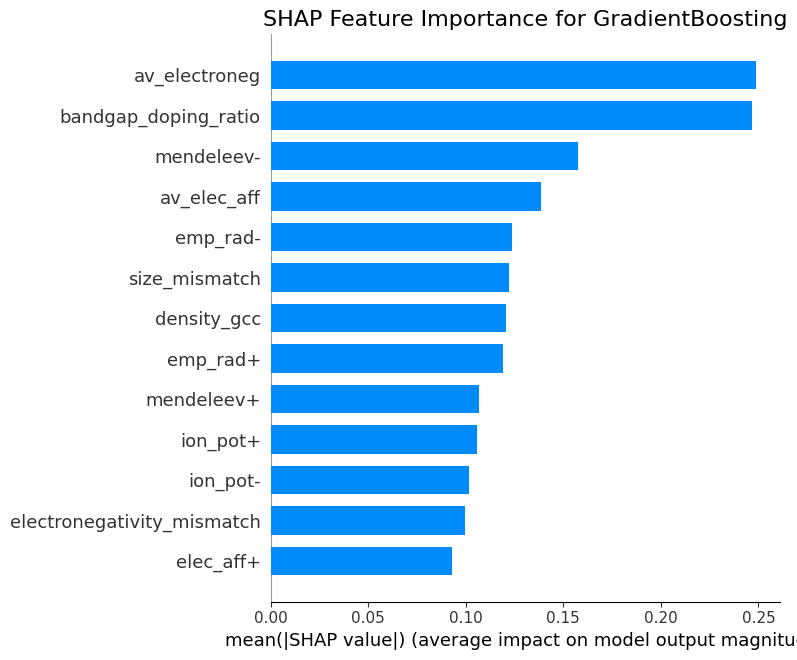

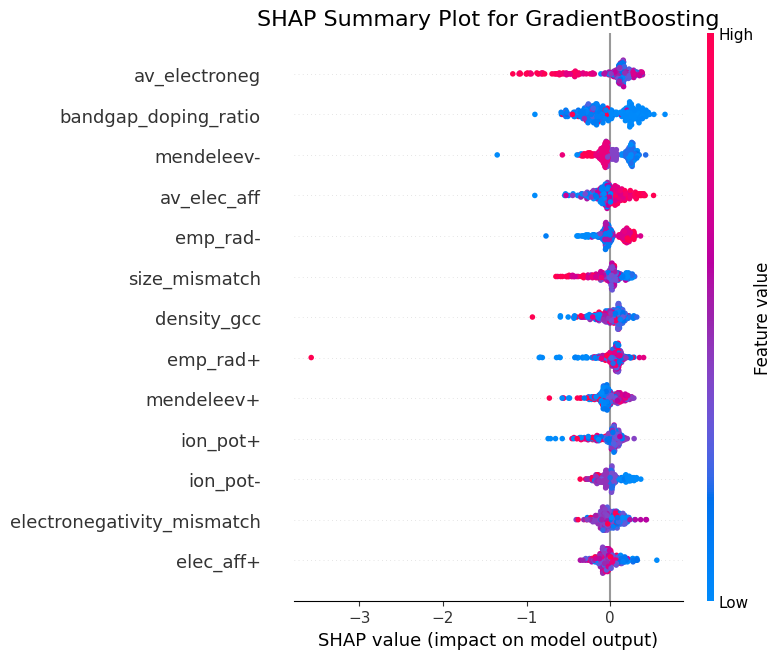

SHAP Summary Plots generated successfully for GradientBoosting model.


In [ ]:
import shap

print("\n--- Generating SHAP Summary Plot ---")

# Select the best model for SHAP analysis (e.g., RandomForest based on R2 score from results)
# Assuming 'RandomForest' was the best or we want to demonstrate for one specific model.
# You might want to dynamically select the model with the highest R2 if preferred.

best_model_name = max(results, key=lambda k: results[k]['r2_score'])
best_model_for_shap = results[best_model_name]['best_model']

# Re-derive X_selected for the chosen best model for SHAP explanation
current_model_estimator = models_to_tune[best_model_name]['model']
selector = RFECV(estimator=current_model_estimator, step=1, cv=5, scoring='r2', n_jobs=-1)
selector.fit(X, y)
X_selected_for_shap = X.loc[:, selector.support_]

# Create a SHAP Explainer object
# For tree-based models, TreeExplainer is efficient
explainer = shap.TreeExplainer(best_model_for_shap)

# Calculate SHAP values for the selected features
shap_values = explainer.shap_values(X_selected_for_shap)

# Plot the SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_selected_for_shap, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance for {best_model_name}', fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_selected_for_shap, show=False)
plt.title(f'SHAP Summary Plot for {best_model_name}', fontsize=16)
plt.tight_layout()
plt.show()

print(f"SHAP Summary Plots generated successfully for {best_model_name} model.")
